In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html

import nltk
from nltk.corpus import reuters, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load the Dataset

In [ ]:
aaaaasfgdsjkfheksdfhedlhfoeiqhfilefjjkehfjehfehfkehflehfednflewjhfeilqwf

In [ ]:
# Load and Combine Datasets
# 0 = Non-toxic
# 1 = Toxic

dataset_1 = pd.read_csv('../data/FinalBalancedDataset.csv')
dataset_2 = pd.read_csv('../data/twitter_toxic_tweets.csv')

dataset_1 = dataset_1.rename(columns={'Toxicity': 'label'})

dataset_1 = dataset_1[['label', 'tweet']]
dataset_2 = dataset_2[['label', 'tweet']]

df = pd.concat([dataset_1, dataset_2], ignore_index=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


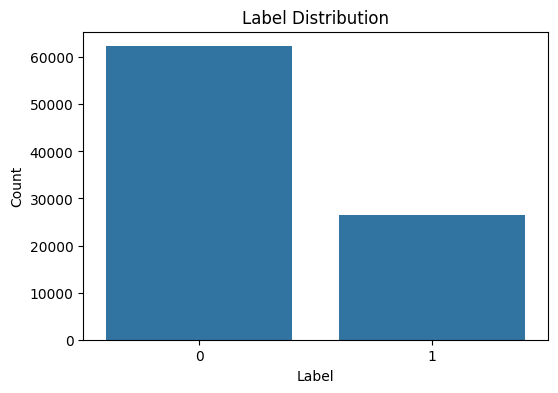

In [ ]:
# Visualize the Distribution of Labels

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Pre-processing

In [ ]:
# Lowercase

df['tweet'] = df['tweet'].str.lower()
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [ ]:
# Check for URL or HTML Tags

have_url = df["tweet"].str.contains('http\S+|www\S+', regex=True).any()
have_html = df["tweet"].str.contains('<.*?>', regex=True).any()

print("Rows contain URL:", have_url)
print("Rows contain HTML:", have_html)

Rows contain URL: True
Rows contain HTML: False


<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Yohana\AppData\Local\Temp\ipykernel_15212\3178551942.py:2: SyntaxWarning: invalid escape sequence '\S'
  have_url = df["tweet"].str.contains('http\S+|www\S+', regex=True).any()


In [ ]:
# Remove URL

def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

df['tweet'] = df['tweet'].apply(remove_url)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [ ]:
# Remove HTML entities like & (&amp;), < (&lt;), " (&quot;)

df['tweet'] = df['tweet'].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [ ]:
# Remove @user before the @ is removed from removing the punctuation

def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

df['tweet'] = df['tweet'].apply(remove_mentions)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for #lyft credit i can't use cause th...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [ ]:
# Remove symbols and numbers

def remove_symbols(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['tweet'] = df['tweet'].apply(remove_symbols)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for lyft credit i cant use cause they...
2,0,bihday your majesty
3,0,model i love u take with u all the time in u...
4,0,factsguide society now motivation


In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_words = ['im', 'u', 'ur','user', 'get', 'got', 'rt']
stop_words.update(custom_words)

# Remove stopwords
def remove_stopwords(text):
    # Split text, keep word ONLY if it is not in stopwords
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

df['tweet'] = df['tweet'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,tweet
0,0,father dysfunctional selfish drags kids dysfun...
1,0,thanks lyft credit cant use cause dont offer w...
2,0,bihday majesty
3,0,model love take time
4,0,factsguide society motivation


In [ ]:
from sklearn.utils import resample
import pandas as pd

# Find the size of the smallest class
min_size = df['label'].value_counts().min()

# Create an empty list to hold resampled dataframes
resampled_dfs = []

# Loop through each unique label (dropping NaNs)
for label in df['label'].dropna().unique():
    sub_df = df[df['label'] == label]
    
    # Downsample the majority classes to match min_size
    df_resampled = resample(sub_df, replace=False, n_samples=min_size, random_state=42)
    resampled_dfs.append(df_resampled)

# Concatenate everything and reset index
df_balanced = pd.concat(resampled_dfs, ignore_index=True)

print("Distribution after balancing:")
print(df_balanced['label'].value_counts())

Distribution after balancing:
label
0    26395
1    26395
Name: count, dtype: int64


In [12]:
# Tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

df_balanced['tweet'] = df_balanced['tweet'].apply(word_tokenize)
df_balanced.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,label,tweet
0,0,"[checked, flight, cincinnati, ragt, tomorrow, ..."
1,0,"[friday, nights, fridays, weekend]"
2,0,"[bihday, pac, pac, starin, rear, view, music, ..."
3,0,"[add, close, peepz, staycloseofamily, sunday, ..."
4,0,"[good, leaders, take, advantage, change, gener..."


- An anomaly was found where even after removing stopwords, the word 'as' would still appear in the final check of top 20 words. The cause was identified where the word 'ass' would be lemmatized as 'as'. So a condition was added during lemmatization

In [13]:
# Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(word_list):
    # If the word is 'ass', leave it alone. Otherwise, lemmatize normally.
    return [word if word == 'ass' else lemmatizer.lemmatize(word) for word in word_list]

df_balanced['tweet'] = df_balanced['tweet'].apply(lemmatize_text)
df_balanced.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,label,tweet
0,0,"[checked, flight, cincinnati, ragt, tomorrow, ..."
1,0,"[friday, night, friday, weekend]"
2,0,"[bihday, pac, pac, starin, rear, view, music, ..."
3,0,"[add, close, peepz, staycloseofamily, sunday, ..."
4,0,"[good, leader, take, advantage, change, genera..."


In [14]:
# Final Check of Top 20 Most Common Words
all_words = [word for sublist in df_balanced['tweet'] for word in sublist]

word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

print('\nMost common words:')
for word, count in most_common_words:
    print(f'{word}: {count}')


Most common words:
bitch: 11395
hoe: 4285
like: 3805
love: 3066
day: 2797
dont: 2428
pussy: 2280
nigga: 2048
ass: 1666
happy: 1620
fuck: 1571
time: 1485
one: 1471
shit: 1389
cant: 1377
life: 1376
go: 1323
make: 1288
people: 1277
want: 1261


# Data Visualization

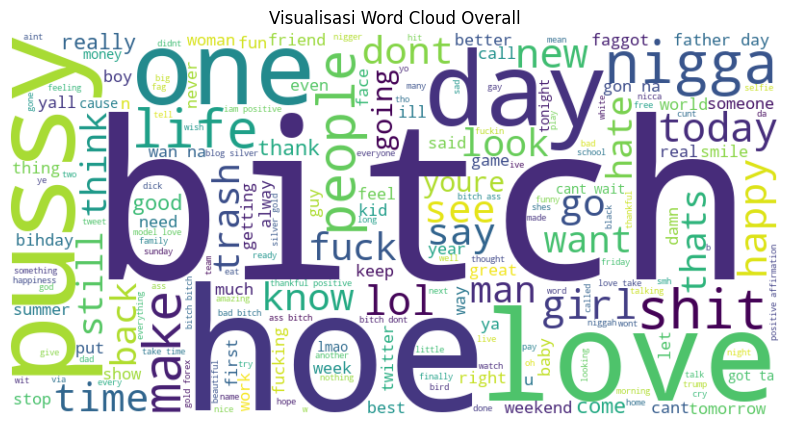

In [15]:
# Word Cloud
def plot_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Visualisasi Word Cloud Overall")
    plt.show()

all_words = []

for tokens in df_balanced['tweet']:
    all_words.extend(tokens)

plot_wordcloud(" ".join(all_words))

# Train Test Split

In [17]:
X = df_balanced['tweet'].astype(str)
y = df_balanced['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Modeling and Evaluation


Naive Bayes Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.93      0.86      0.90      5256
       Toxic       0.87      0.94      0.90      5302

    accuracy                           0.90     10558
   macro avg       0.90      0.90      0.90     10558
weighted avg       0.90      0.90      0.90     10558



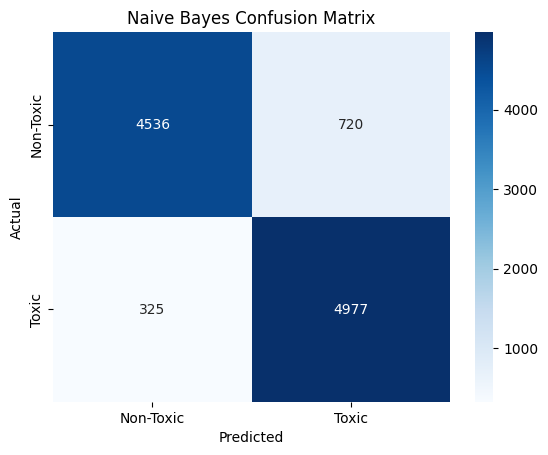


KNN Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.63      0.94      0.75      5256
       Toxic       0.89      0.45      0.59      5302

    accuracy                           0.69     10558
   macro avg       0.76      0.70      0.67     10558
weighted avg       0.76      0.69      0.67     10558



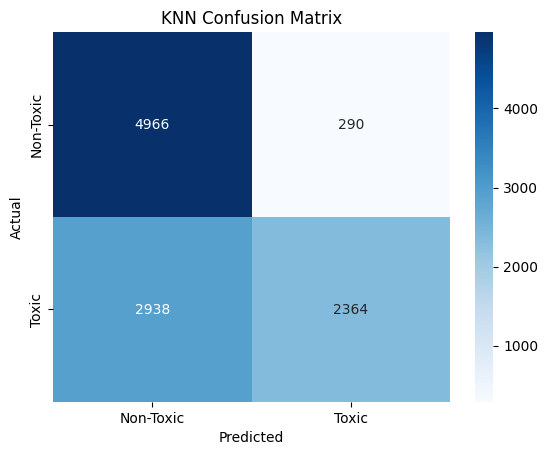


SVM Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.92      0.96      0.94      5256
       Toxic       0.96      0.92      0.94      5302

    accuracy                           0.94     10558
   macro avg       0.94      0.94      0.94     10558
weighted avg       0.94      0.94      0.94     10558



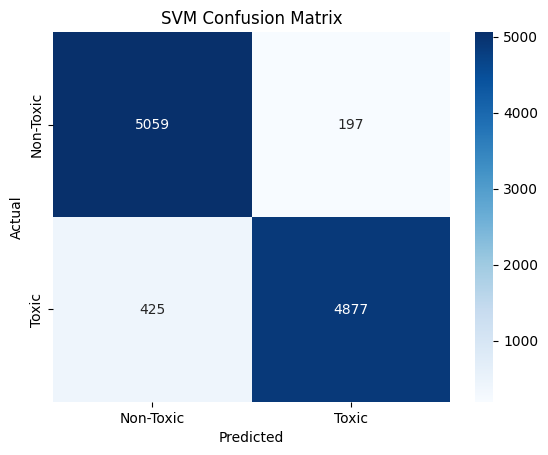


Logistic Regression Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.91      0.96      0.94      5256
       Toxic       0.96      0.91      0.93      5302

    accuracy                           0.94     10558
   macro avg       0.94      0.94      0.94     10558
weighted avg       0.94      0.94      0.94     10558



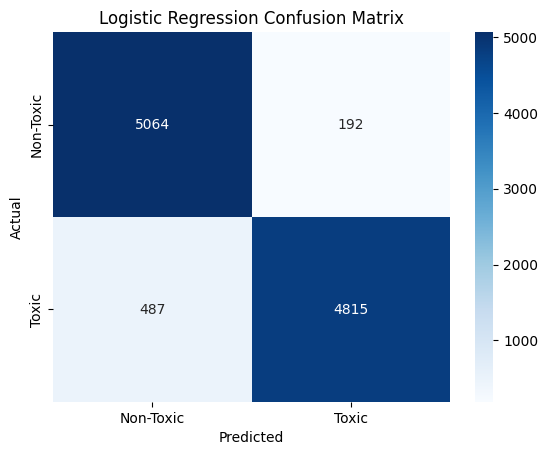


Random Forest Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.95      0.95      5256
       Toxic       0.95      0.96      0.95      5302

    accuracy                           0.95     10558
   macro avg       0.95      0.95      0.95     10558
weighted avg       0.95      0.95      0.95     10558



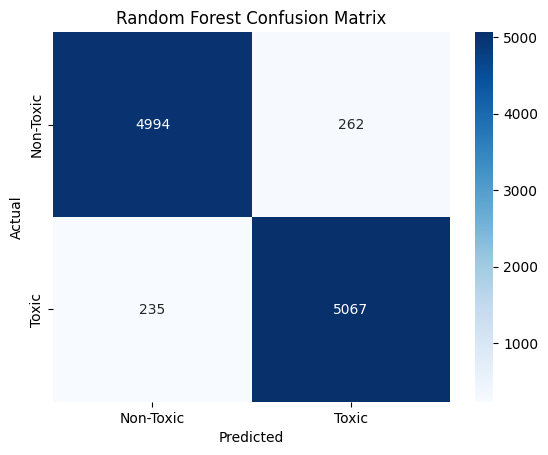


XGBoost Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.88      0.97      0.92      5256
       Toxic       0.97      0.87      0.92      5302

    accuracy                           0.92     10558
   macro avg       0.93      0.92      0.92     10558
weighted avg       0.93      0.92      0.92     10558



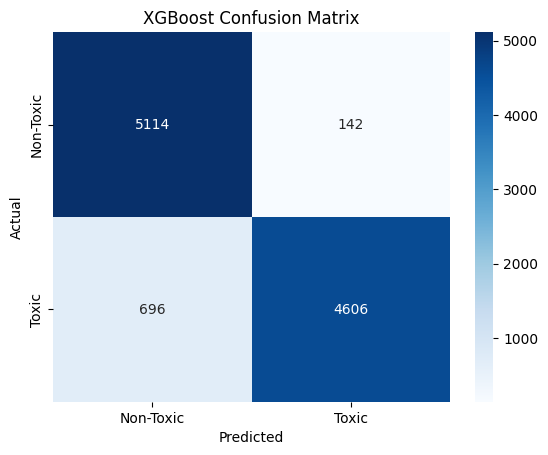

In [ ]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear', random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
    
}

f1_results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Toxic', 'Toxic']))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    f1_results[name] = f1_score(y_test, y_pred, average='weighted')

C:\Users\Yohana\AppData\Local\Temp\ipykernel_15212\2565825761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_results.keys()), y=list(f1_results.values()), palette='viridis')


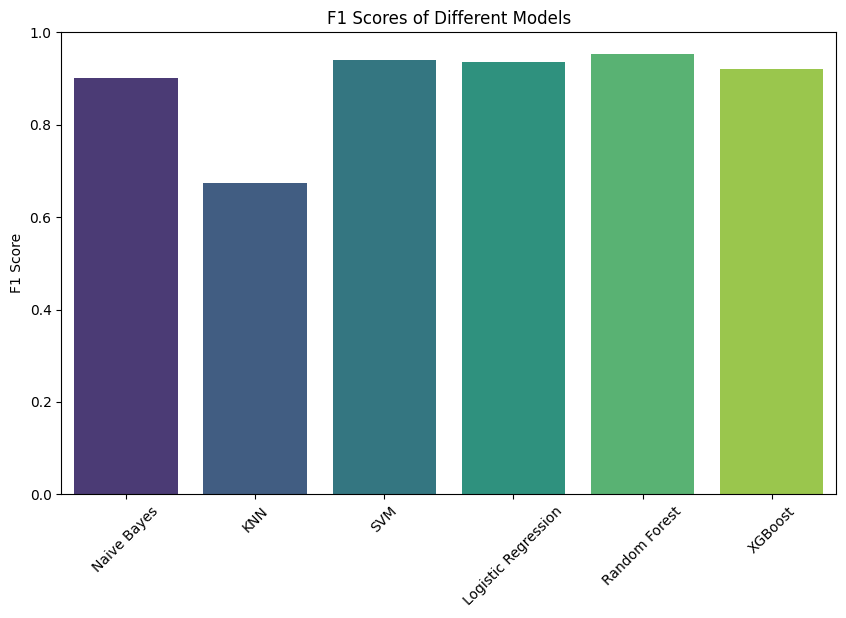

In [ ]:
# Plot F1 scores

plt.figure(figsize=(10, 6))
sns.barplot(x=list(f1_results.keys()), y=list(f1_results.values()), palette='viridis')
plt.title('F1 Scores of Different Models')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

C:\Users\Yohana\AppData\Local\Temp\ipykernel_15212\802171915.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


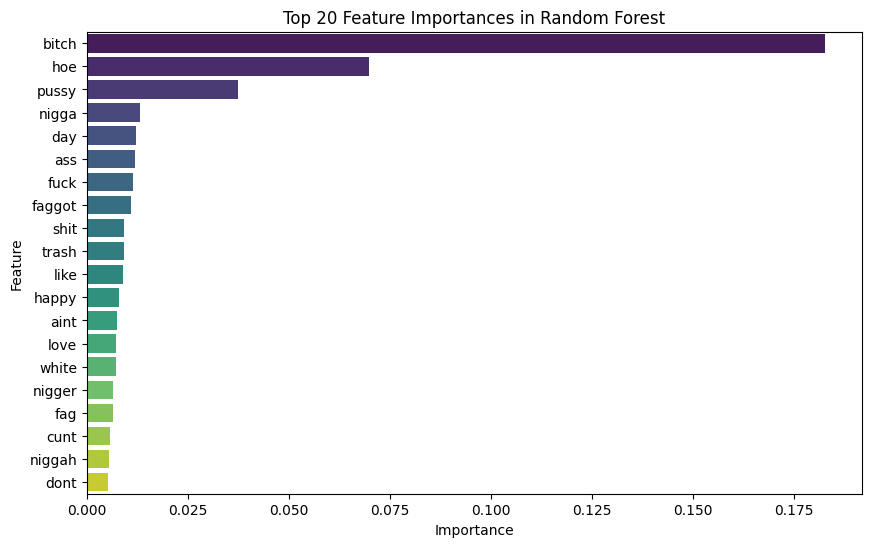

In [ ]:
# Check Random Forest Feature Importance

rf_model = models["Random Forest"]
feature_importances = rf_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Feature Importances in Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

Best Random Forest Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.95      0.95      5256
       Toxic       0.95      0.96      0.96      5302

    accuracy                           0.96     10558
   macro avg       0.96      0.96      0.96     10558
weighted avg       0.96      0.96      0.96     10558



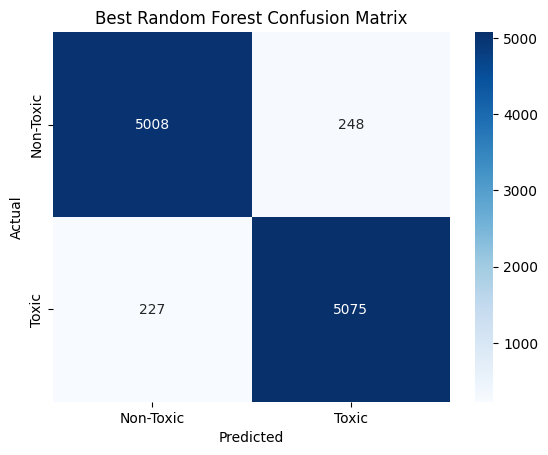

In [ ]:
# Hyperparameter Tuning for Random Forest

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_tfidf, y_train)
print(f"Best parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_tfidf)
print("\nBest Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Toxic', 'Toxic']))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Best Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()